In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix)

np.random.seed(42)

# create customer churn dataset with 200 customers
n = 200

data = {
    'Age'           : np.random.randint(18, 70, n),
    'Gender'        : np.random.choice(['Male', 'Female'], n),
    'MonthlyCharges': np.random.randint(20, 120, n),
    'Tenure'        : np.random.randint(1, 72, n),
    'NumProducts'   : np.random.randint(1, 5, n),
    'HasComplained' : np.random.choice([0, 1], n),
}

df = pd.DataFrame(data)

# create churn column based on customer behaviour
churn_prob = (
    (df['MonthlyCharges'] > 80).astype(int) * 0.4 +
    (df['HasComplained'] == 1).astype(int) * 0.3 +
    (df['NumProducts'] < 2).astype(int) * 0.2 +
    (df['Tenure'] < 12).astype(int) * 0.1
)

df['Churn'] = (churn_prob +
               np.random.uniform(0, 0.3, n) > 0.5).astype(int)

df.to_csv('churn_data.csv', index=False)

print("dataset created!")
print(f"total customers  : {len(df)}")
print(f"churned customers: {df['Churn'].sum()}")
print(f"stayed customers : {(df['Churn']==0).sum()}")
print(df.head())

dataset created!
total customers  : 200
churned customers: 103
stayed customers : 97
   Age  Gender  MonthlyCharges  Tenure  NumProducts  HasComplained  Churn
0   56  Female              27      12            3              1      0
1   69  Female              46      50            1              0      0
2   46    Male              46      35            1              0      0
3   32    Male             117      33            4              0      1
4   60  Female              40      33            2              0      0


=== dataset overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Age             200 non-null    int64 
 1   Gender          200 non-null    object
 2   MonthlyCharges  200 non-null    int64 
 3   Tenure          200 non-null    int64 
 4   NumProducts     200 non-null    int64 
 5   HasComplained   200 non-null    int64 
 6   Churn           200 non-null    int64 
dtypes: int64(6), object(1)
memory usage: 11.1+ KB
None

=== summary statistics ===
             Age  MonthlyCharges      Tenure  NumProducts  HasComplained  \
count  200.00000      200.000000  200.000000    200.00000     200.000000   
mean    43.42500       70.295000   34.395000      2.47500       0.525000   
std     14.94191       29.926845   19.961998      1.06066       0.500628   
min     18.00000       20.000000    1.000000      1.00000       0.000000   
25%     31.

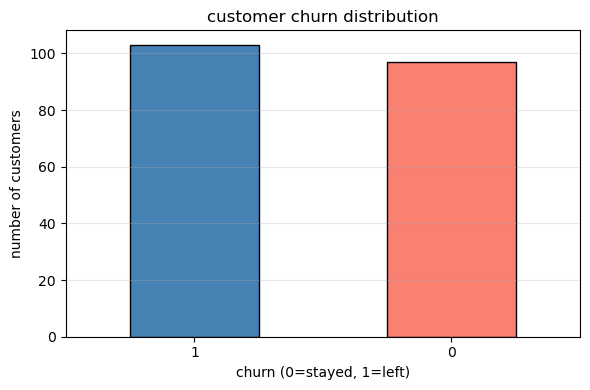

churn distribution chart saved!


In [2]:
df = pd.read_csv('churn_data.csv')

print(" dataset overview ")
print(df.info())
print("\n summary statistics ")
print(df.describe())

# plot churn distribution
plt.figure(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar',
                                color=['steelblue','salmon'],
                                edgecolor='black')
plt.title('customer churn distribution')
plt.xlabel('churn (0=stayed, 1=left)')
plt.ylabel('number of customers')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('churn_distribution.png')
plt.show()
print("churn distribution chart saved!")

In [3]:
# encode gender into numbers
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

print("gender encoding done:")
print("0 = Female, 1 = Male")

# define features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"\nfeatures used: {list(X.columns)}")

# split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\ntraining set: {len(X_train)} customers")
print(f"testing set : {len(X_test)} customers")
print("preprocessing complete!")

gender encoding done:
0 = Female, 1 = Male

features used: ['Age', 'Gender', 'MonthlyCharges', 'Tenure', 'NumProducts', 'HasComplained']

training set: 160 customers
testing set : 40 customers
preprocessing complete!


In [4]:
# model 1 - decision tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_preds = dt_model.predict(X_test_scaled)

# model 2 - logistic regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

# model 3 - random forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

print("all three models trained!")
print("1. decision tree")
print("2. logistic regression")
print("3. random forest")

all three models trained!
1. decision tree
2. logistic regression
3. random forest


In [5]:
models = {
    'Decision Tree'      : dt_preds,
    'Logistic Regression': lr_preds,
    'Random Forest'      : rf_preds
}

print("=== model comparison ===\n")
results = []

for name, preds in models.items():
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec  = recall_score(y_test, preds, zero_division=0)
    f1   = f1_score(y_test, preds, zero_division=0)

    results.append({
        'Model'    : name,
        'Accuracy' : round(acc, 4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec, 4),
        'F1-Score' : round(f1, 4)
    })

    print(f"{name}:")
    print(f"  accuracy  : {acc*100:.2f}%")
    print(f"  precision : {prec*100:.2f}%")
    print(f"  recall    : {rec*100:.2f}%")
    print(f"  f1-score  : {f1*100:.2f}%\n")

results_df = pd.DataFrame(results)
print(results_df)

=== model comparison ===

Decision Tree:
  accuracy  : 77.50%
  precision : 89.47%
  recall    : 70.83%
  f1-score  : 79.07%

Logistic Regression:
  accuracy  : 80.00%
  precision : 90.00%
  recall    : 75.00%
  f1-score  : 81.82%

Random Forest:
  accuracy  : 82.50%
  precision : 94.74%
  recall    : 75.00%
  f1-score  : 83.72%

                 Model  Accuracy  Precision  Recall  F1-Score
0        Decision Tree     0.775     0.8947  0.7083    0.7907
1  Logistic Regression     0.800     0.9000  0.7500    0.8182
2        Random Forest     0.825     0.9474  0.7500    0.8372


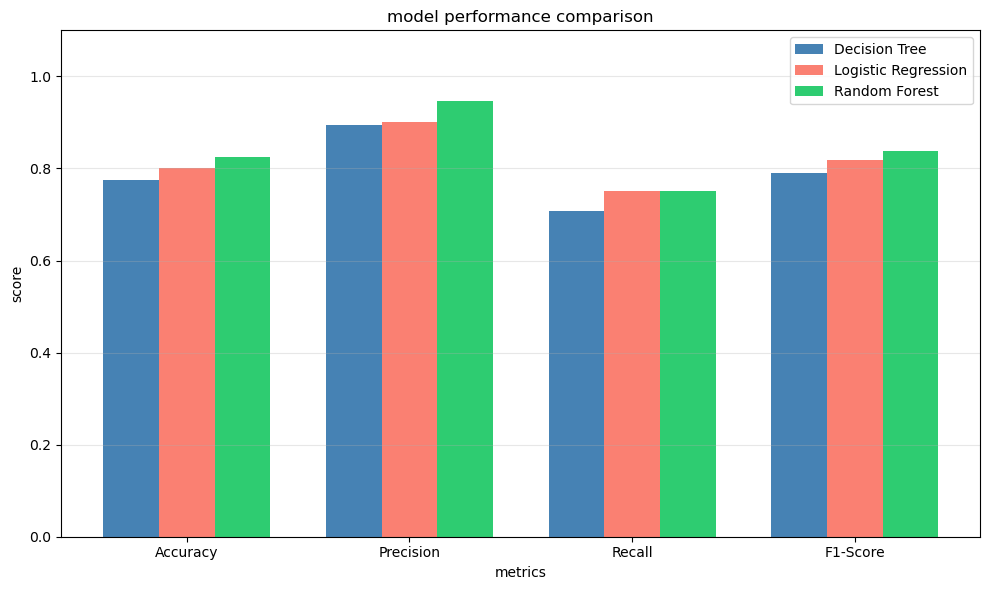

model comparison chart saved!


In [6]:
metrics = ['Accuracy','Precision','Recall','F1-Score']

plt.figure(figsize=(10, 6))

x     = np.arange(len(metrics))
width = 0.25

plt.bar(x - width,
        results_df[results_df['Model']=='Decision Tree'][metrics].values[0],
        width, label='Decision Tree', color='steelblue')

plt.bar(x,
        results_df[results_df['Model']=='Logistic Regression'][metrics].values[0],
        width, label='Logistic Regression', color='salmon')

plt.bar(x + width,
        results_df[results_df['Model']=='Random Forest'][metrics].values[0],
        width, label='Random Forest', color='#2ECC71')

plt.title('model performance comparison')
plt.xlabel('metrics')
plt.ylabel('score')
plt.xticks(x, metrics)
plt.legend()
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()
print("model comparison chart saved!")

In [7]:
print("running grid search... this may take a minute")

param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
best_preds = best_model.predict(X_test_scaled)

print(f"best settings found:")
print(f"{grid_search.best_params_}")
print(f"\n=== tuned model performance ===")
print(f"accuracy  : {accuracy_score(y_test, best_preds)*100:.2f}%")
print(f"precision : {precision_score(y_test, best_preds, zero_division=0)*100:.2f}%")
print(f"recall    : {recall_score(y_test, best_preds, zero_division=0)*100:.2f}%")
print(f"f1-score  : {f1_score(y_test, best_preds, zero_division=0)*100:.2f}%")

running grid search... this may take a minute
best settings found:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}

=== tuned model performance ===
accuracy  : 85.00%
precision : 95.00%
recall    : 79.17%
f1-score  : 86.36%


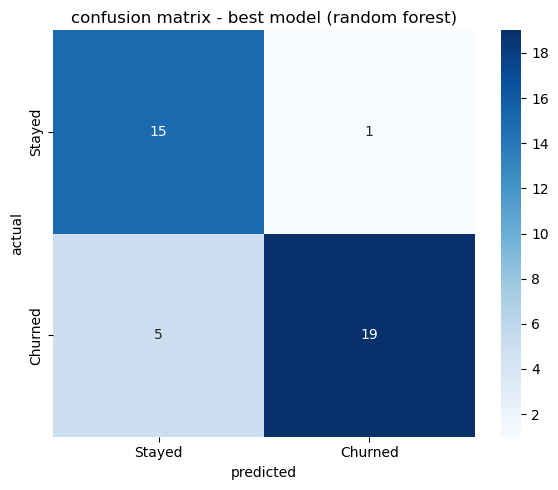

confusion matrix saved!


In [8]:
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Stayed','Churned'],
            yticklabels=['Stayed','Churned'])

plt.title('confusion matrix - best model (random forest)')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
print("confusion matrix saved!")

In [9]:

print("   classification task complete!         ")
print(f"\ndataset      : {len(df)} customers")
print(f"target       : customer churn prediction")
print(f"models used  : decision tree, logistic regression, random forest")
print(f"best model   : random forest (after grid search tuning)")
print(f"\nfiles saved:")
print("   - churn_data.csv")
print("   - churn_distribution.png")
print("   - model_comparison.png")
print("   - confusion_matrix.png")

   classification task complete!         

dataset      : 200 customers
target       : customer churn prediction
models used  : decision tree, logistic regression, random forest
best model   : random forest (after grid search tuning)

files saved:
   - churn_data.csv
   - churn_distribution.png
   - model_comparison.png
   - confusion_matrix.png
